<a href="https://colab.research.google.com/github/Anagha264/Anagha/blob/master/mainmajor_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive'))

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']


In [ ]:
print(os.listdir('/content/drive/MyDrive/majorproject/dataset'))

['train', 'test']


In [ ]:
train_dir = "/content/drive/MyDrive/majorproject/dataset/train"
test_dir = "/content/drive/MyDrive/majorproject/dataset/test"

In [ ]:
import os
import shutil
import random

# ================= PATH =================
original_train_dir = "/content/drive/MyDrive/majorproject/dataset/train"
balanced_train_dir = "/content/drive/MyDrive/majorproject/dataset_balanced/train"

# ================= CREATE NEW FOLDER =================
os.makedirs(balanced_train_dir, exist_ok=True)

# ================= FIND MIN COUNT =================
class_counts = {}
for class_name in os.listdir(original_train_dir):
    class_path = os.path.join(original_train_dir, class_name)
    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path) if f.endswith(('.jpg','.png','.jpeg'))]
        class_counts[class_name] = len(images)

min_count = min(class_counts.values())
print("Minimum images per class:", min_count)

# ================= COPY EQUAL IMAGES =================
for class_name in os.listdir(original_train_dir):
    src_class_path = os.path.join(original_train_dir, class_name)
    dst_class_path = os.path.join(balanced_train_dir, class_name)

    os.makedirs(dst_class_path, exist_ok=True)

    images = [f for f in os.listdir(src_class_path) if f.endswith(('.jpg','.png','.jpeg'))]

    # Randomly pick min_count images
    selected_images = random.sample(images, min_count)

    for img in selected_images:
        src_path = os.path.join(src_class_path, img)
        dst_path = os.path.join(dst_class_path, img)

        shutil.copy(src_path, dst_path)

print("✅ Balanced dataset created successfully!")

Minimum images per class: 884
✅ Balanced dataset created successfully!


Mounted at /content/drive

🚀 Training ResNet...

Found 2128 images belonging to 3 classes.
Found 530 images belonging to 3 classes.
Found 648 images belonging to 3 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 789s 12s/step - accuracy: 0.7110 - loss: 0.8486 - val_accuracy: 0.4887 - val_loss: 2.9695 - learning_rate: 0.0010
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 347s 5s/step - accuracy: 0.7552 - loss: 0.5810 - val_accuracy: 0.5566 - val_loss: 2.1748 - learning_rate: 0.0010
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 350s 5s/step - accuracy: 0.7669 - loss: 0.5520 - val_accuracy: 0.5774 - val_loss: 1.0053 - learning_rate: 0.0010
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 371s 6s/step - accuracy: 0.7768 - loss: 0.5278 - val_accuracy: 0.6189 - val_loss: 1.1598 - learning_rate: 0.0010
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 353s 5s/step - accuracy: 0.7918 - loss: 0.4923 - val_accuracy: 0.6226 - val_loss: 0.8363 - learning_rate: 0.0010
Epoch 6/50
67/67 ━━━

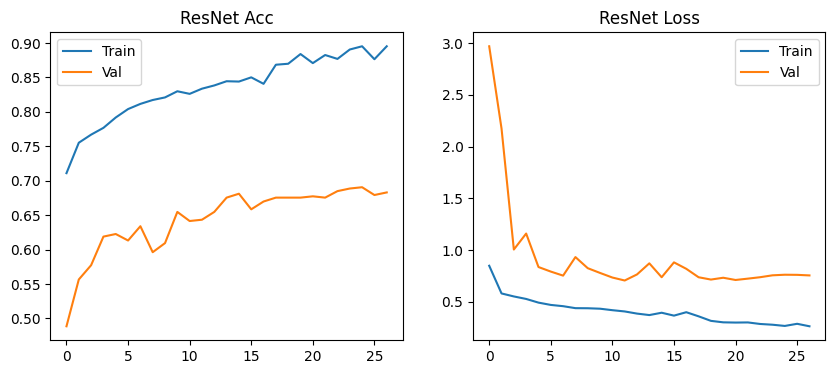

21/21 ━━━━━━━━━━━━━━━━━━━━ 210s 10s/step

📊 ResNet Report:
               precision    recall  f1-score   support

      normal       0.82      0.48      0.60       227
  osteopenia       0.64      0.80      0.71       186
osteoporosis       0.57      0.69      0.62       235

    accuracy                           0.65       648
   macro avg       0.68      0.65      0.64       648
weighted avg       0.68      0.65      0.64       648


🚀 Training VGG19...

Found 2128 images belonging to 3 classes.
Found 530 images belonging to 3 classes.
Found 648 images belonging to 3 classes.
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1140s 17s/step - accuracy: 0.3304 - loss: 2.1233 - val_accuracy: 0.3321 - val_loss: 1.0987 - learning_rate: 0.0010
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1166s 17s/step - accuracy: 0.3247 - loss: 1.0989 - val_accuracy: 0.3358 - val_loss: 1.0986 - learning_rate: 0.0010
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1136s 17s/step - a

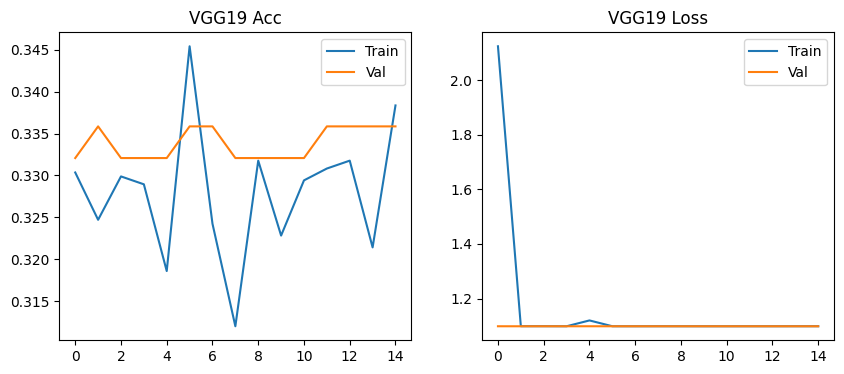

21/21 ━━━━━━━━━━━━━━━━━━━━ 231s 11s/step

📊 VGG19 Report:
               precision    recall  f1-score   support

      normal       0.00      0.00      0.00       227
  osteopenia       0.00      0.00      0.00       186
osteoporosis       0.36      1.00      0.53       235

    accuracy                           0.36       648
   macro avg       0.12      0.33      0.18       648
weighted avg       0.13      0.36      0.19       648


🚀 Training DenseNet...

Found 2128 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Found 530 images belonging to 3 classes.
Found 648 images belonging to 3 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 286s 4s/step - accuracy: 0.6433 - loss: 0.8904 - val_accuracy: 0.6057 - val_loss: 1.0889 - learning_rate: 0.0010
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.7547 - loss: 0.5710 - val_accuracy: 0.5962 - val_loss: 0.9942 - learning_rate: 0.0010
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.7796 - loss: 0.5253 - val_accuracy: 0.6321 - val_loss: 0.7728 - learning_rate: 0.0010
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.8040 - loss: 0.4901 - val_accuracy: 0.5906 - val_loss: 0.8641 - learning_rate: 0.0010
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7945 - loss: 0.4994
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
67/67 ━━━━━━━━━━━━━━━━━━━━ 263s 4s/step - accuracy: 0.8003 - loss: 0.4757 - val_accuracy: 0.6377 - val_

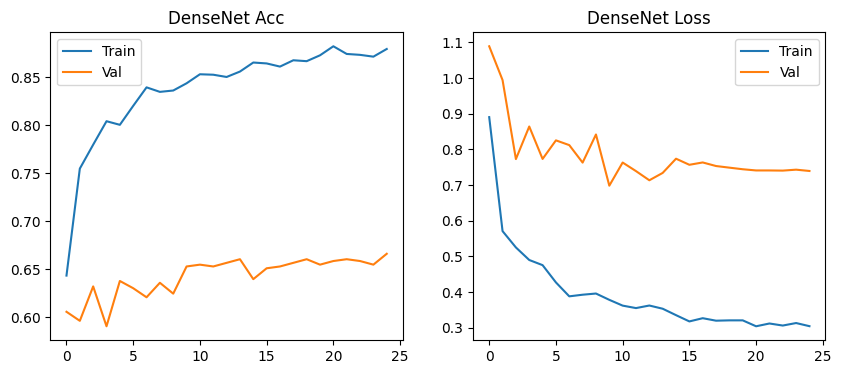

21/21 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step

📊 DenseNet Report:
               precision    recall  f1-score   support

      normal       0.75      0.52      0.61       227
  osteopenia       0.66      0.87      0.75       186
osteoporosis       0.60      0.63      0.62       235

    accuracy                           0.66       648
   macro avg       0.67      0.67      0.66       648
weighted avg       0.67      0.66      0.65       648


🚀 Training AlexNet...

Found 2128 images belonging to 3 classes.
Found 530 images belonging to 3 classes.
Found 648 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.5602 - loss: 1.2583 - val_accuracy: 0.4868 - val_loss: 1.0115 - learning_rate: 0.0010
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 194s 3s/step - accuracy: 0.6109 - loss: 0.8217 - val_accuracy: 0.5377 - val_loss: 0.8892 - learning_rate: 0.0010
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.6335 - loss: 0.7705 - val_accuracy: 0.5925 - val_loss: 0.8240 - learning_rate: 0.0010
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.6405 - loss: 0.7319 - val_accuracy: 0.5755 - val_loss: 0.8877 - learning_rate: 0.0010
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6404 - loss: 0.7296
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
67/67 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.6447 - loss: 0.7149 - val_accuracy: 0.5717 - val_loss: 1.0387 - learning_rate: 0.0010
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.6819 - loss: 0.6496 - val_accur

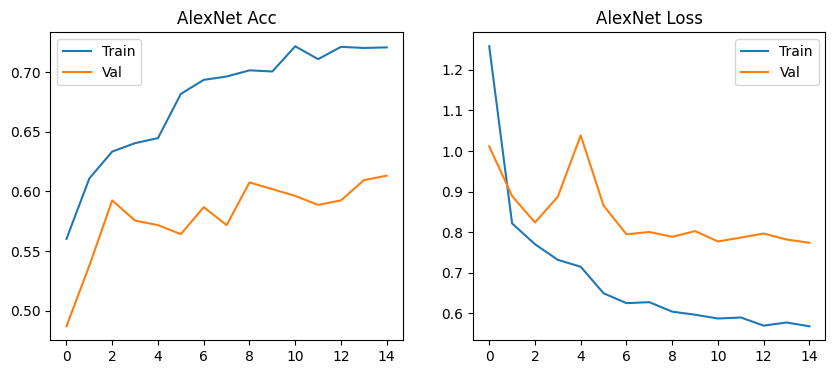

21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 639ms/step

📊 AlexNet Report:
               precision    recall  f1-score   support

      normal       0.43      0.66      0.52       227
  osteopenia       0.54      0.51      0.52       186
osteoporosis       0.28      0.15      0.20       235

    accuracy                           0.43       648
   macro avg       0.42      0.44      0.41       648
weighted avg       0.41      0.43      0.40       648



In [1]:
# ================== MOUNT DRIVE ==================
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, VGG19, DenseNet121
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

# ================== PATH & PARAMS ==================
train_dir = "/content/drive/MyDrive/majorproject/dataset_balanced/train"
test_dir = "/content/drive/MyDrive/majorproject/dataset/test"
img_size = 160
batch_size = 32 # Increased for better stability
epochs = 50

# ============= IMPROVED CALLBACKS =============
# Increased patience so the model doesn't quit while still learning
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# ============= FIXED DATA GENERATORS =============
def get_generators(preprocess_fn):
    # Training gets augmentation
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        validation_split=0.2,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Validation must be CLEAN (no random rotations/zooms)
    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        validation_split=0.2
    )

    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_gen = train_datagen.flow_from_directory(
        train_dir, target_size=(img_size,img_size),
        batch_size=batch_size, class_mode='categorical', subset='training'
    )

    val_gen = val_datagen.flow_from_directory(
        train_dir, target_size=(img_size,img_size),
        batch_size=batch_size, class_mode='categorical', subset='validation'
    )

    test_gen = test_datagen.flow_from_directory(
        test_dir, target_size=(img_size,img_size),
        batch_size=batch_size, class_mode='categorical', shuffle=False
    )

    return train_gen, val_gen, test_gen

# ============= UPDATED MODEL BUILDERS =============
def build_resnet():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(160,160,3))
    # Unfreeze the top layers for better adaptation
    for layer in base.layers[:-20]:
        layer.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    out = Dense(3, activation='softmax')(x)
    return Model(base.input, out)

def build_vgg():
    base = VGG19(weights='imagenet', include_top=False, input_shape=(160,160,3))
    # Unfreeze the last convolutional block
    for layer in base.layers[:-5]:
        layer.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(3, activation='softmax')(x)
    return Model(base.input, out)

def build_densenet():
    base = DenseNet121(weights='imagenet', include_top=False, input_shape=(160,160,3))
    for layer in base.layers[:-10]:
        layer.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(3, activation='softmax')(x)
    return Model(base.input, out)

def build_alexnet():
    model = Sequential([
        Conv2D(96,(11,11),strides=4,activation='relu',input_shape=(160,160,3)),
        BatchNormalization(),
        MaxPooling2D((3,3),strides=2),
        Conv2D(256,(5,5),padding='same',activation='relu'),
        BatchNormalization(),
        MaxPooling2D((3,3),strides=2),
        Conv2D(384,(3,3),padding='same',activation='relu'),
        Conv2D(256,(3,3),padding='same',activation='relu'),
        MaxPooling2D((3,3),strides=2),
        Flatten(),
        Dense(1024,activation='relu'),
        Dropout(0.5),
        Dense(3,activation='softmax')
    ])
    return model

def alexnet_preprocess(img):
    return img / 255.0

# ================== TRAIN FUNCTION ==================
def train_model(builder, name, preprocess_fn):
    print(f"\n🚀 Training {name}...\n")
    train_gen, val_gen, test_gen = get_generators(preprocess_fn)
    model = builder()

    # Higher initial learning rate (1e-3) to ensure it starts learning
    model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=[early_stop, lr_reduce]
    )

    # Save
    os.makedirs("/content/drive/MyDrive/majorproject/models", exist_ok=True)
    model.save(f"/content/drive/MyDrive/majorproject/models/{name}_poro_model.keras")

    # Plotting
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.title(f'{name} Acc'); plt.legend()
    plt.subplot(1,2,2); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.title(f'{name} Loss'); plt.legend()
    plt.show()

    # Evaluate
    y_pred = np.argmax(model.predict(test_gen), axis=1)
    print(f"\n📊 {name} Report:\n", classification_report(test_gen.classes, y_pred, target_names=list(test_gen.class_indices.keys())))

# ================== EXECUTE ==================
train_model(build_resnet, "ResNet", resnet_preprocess)
train_model(build_vgg, "VGG19", vgg_preprocess)
train_model(build_densenet, "DenseNet", densenet_preprocess)
train_model(build_alexnet, "AlexNet", alexnet_preprocess)


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All models loaded
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step

🔍 Individual Model Predictions (%):
ResNet: [ 4.7038937 43.851902  51.44421  ]
VGG19: [33.2155   33.105244 33.67925 ]
DenseNet: [26.18775  56.214924 17.597324]
AlexNet: [35.35636  28.484467 36.15917 ]

🔥 Ensemble Probabilities:
normal: 26.05%
osteopenia: 40.80%
osteoporosis: 33.15%

✅ Final Prediction: osteopenia
Confidence: 40.80%

⚠️ Borderline case between osteopenia and osteoporosis
⚠️ Possible early-stage Osteoporosis


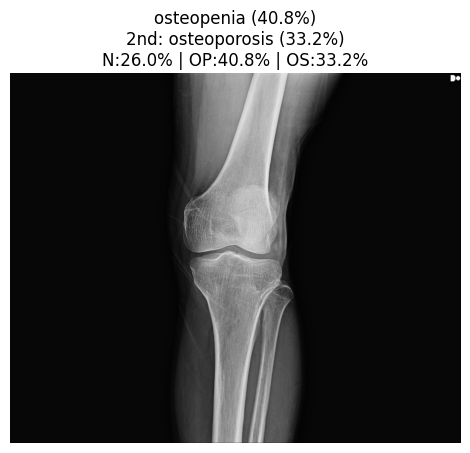

In [60]:
# ================== IMPORTS ==================
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

# ================== MOUNT DRIVE ==================
from google.colab import drive
drive.mount('/content/drive')

# ================== LOAD MODELS ==================
base_path = "/content/drive/MyDrive/majorproject/models/"

resnet = load_model(base_path + "ResNet_poro_model.keras")
vgg = load_model(base_path + "VGG19_poro_model.keras")
densenet = load_model(base_path + "DenseNet_poro_model.keras")
alexnet = load_model(base_path + "AlexNet_poro_model.keras")

print("✅ All models loaded")

# ================== CLASS NAMES ==================
class_names = ['normal', 'osteopenia', 'osteoporosis']

# ================== LOAD IMAGE ==================
img_path = "/content/drive/MyDrive/test_image2.jpg"  # change image here

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ================== RESIZE ==================
img_resized = cv2.resize(img, (160,160))

# ================== CORRECT PREPROCESSING ==================
img_resnet = resnet_preprocess(np.expand_dims(img_resized.copy(), axis=0))
img_vgg = vgg_preprocess(np.expand_dims(img_resized.copy(), axis=0))
img_densenet = densenet_preprocess(np.expand_dims(img_resized.copy(), axis=0))
img_alexnet = np.expand_dims(img_resized / 255.0, axis=0)

# ================== MODEL PREDICTIONS ==================
pred_resnet = resnet.predict(img_resnet)[0]
pred_vgg = vgg.predict(img_vgg)[0]
pred_densenet = densenet.predict(img_densenet)[0]
pred_alexnet = alexnet.predict(img_alexnet)[0]

# ================== WEIGHTED ENSEMBLE ==================
final_probs = (
    0.2 * pred_resnet +
    0.2 * pred_vgg +
    0.3 * pred_densenet +
    0.3 * pred_alexnet
)

# ================== SORT RESULTS ==================
sorted_idx = np.argsort(final_probs)[::-1]

top1 = sorted_idx[0]
top2 = sorted_idx[1]

label = class_names[top1]
confidence = final_probs[top1] * 100

second_label = class_names[top2]
second_conf = final_probs[top2] * 100

gap = confidence - second_conf

# ================== PRINT OUTPUT ==================
print("\n🔍 Individual Model Predictions (%):")
print("ResNet:", pred_resnet * 100)
print("VGG19:", pred_vgg * 100)
print("DenseNet:", pred_densenet * 100)
print("AlexNet:", pred_alexnet * 100)

print("\n🔥 Ensemble Probabilities:")
for i, name in enumerate(class_names):
    print(f"{name}: {final_probs[i]*100:.2f}%")

print("\n✅ Final Prediction:", label)
print(f"Confidence: {confidence:.2f}%")

# ================== INTERPRETATION ==================

# Borderline detection
if gap < 10:
    print(f"\n⚠️ Borderline case between {label} and {second_label}")

# Osteopenia vs Osteoporosis confusion handling
if label == "osteopenia" and second_label == "osteoporosis" and gap < 10:
    print("⚠️ Possible early-stage Osteoporosis")

# Reverse case (osteoporosis vs normal → possible osteopenia)
if label == "osteoporosis" and second_label == "normal" and gap < 10:
    print("⚠️ Possible Osteopenia (intermediate stage)")

# Medical safety warning
if final_probs[2] > 0.35:
    print("⚠️ Osteoporosis risk detected")

# ================== DISPLAY ==================
plt.imshow(img)
plt.title(
    f"{label} ({confidence:.1f}%)\n"
    f"2nd: {second_label} ({second_conf:.1f}%)\n"
    f"N:{final_probs[0]*100:.1f}% | "
    f"OP:{final_probs[1]*100:.1f}% | "
    f"OS:{final_probs[2]*100:.1f}%"
)
plt.axis('off')
plt.show()